# Tehtaan kapasiteetti vs. läpäisy: Kaksiulotteinen portfolioanalyysi PROC SGPLOT:lla

## Yhteenveto

Kappaletavaratuotannon tuoteportfoliolla on kaksi lukua, jotka ovat tärkeitä jokaiselle tuotantolinjalle yhtä aikaa: **kuinka paljon konekapasiteettia se kuluttaa** ja **kuinka paljon hyväksyttyä tuotantoa se todella toimittaa**. Yksiulotteinen pylväskaavio voi näyttää vain toisen niistä. Tämä muistikirja visualisoi molemmat yhdessä `PROC SGPLOT`:lla käyttäen **kuplakaaviota** ydinnäkymänä — jokainen linja sijoitetaan kapasiteetin (x) ja läpäisyn (y) mukaan, ja kuplan koko kertoo sen tuottavuusasteen (yksikköä konetuntia kohden). Linjat, jotka sijaitsevat alhaalla oikealla (paljon kapasiteettia, vähän tuotantoa) ovat kapasiteettinieluja; linjat, jotka sijaitsevat ylhäällä vasemmalla suurella kuplalla, ovat korkean tuoton linjoja. Ryhmitelty pylväsnäkymä purkaa sitten läpäisyn tehtaittain, ja tuottavuusjärjestys vahvistaa eron.

Todellista suoritettua tulostetta vasten (kahdeksan tuotantolinjaa kolmella tehtaalla, 100 vuorotason ajoa koottuna 24 linja-tehdas-soluksi), analyysi havaitsee, että **Valu** on portfolion selkein kapasiteettinielu (14,3 hyväksyttyä yksikköä konetuntia kohden — se kuluttaa 10,1 % kokonaiskapasiteetista mutta toimittaa vain 3,2 % hyväksytyistä yksiköistä), kun taas **Pakkaus** on ylivoimainen korkean tuoton linja (119,2 yksikköä tuntia kohden — 9,1 % kapasiteetista tuottaa 23,8 % tuotannosta). Tehtaiden välillä **Stuttgart** käy kuumimmillaan 49,9 yksikköä/h ja **Monterrey** viileimmin 41,6.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Synteettisiä vuorotason tuotantoajoja kahdeksalla tuotantolinjalla, kolmella tehtaalla ja kolmella vuorolla — suunnitellut konetunnit, ajotunnit, seisokit, brutto-/hylky-/hyväksytyt yksiköt (rajattu 100 havaintoon lisensoimattomassa tilassa) | 100 |
| WORK.LINE_CAPACITY | Koottu yhteenveto tuotantolinjaa ja tehdasta kohden: kokonaiskapasiteettitunnit (x), tuotetut hyväksytyt yksiköt (y) ja hyväksyttyjen yksiköiden saanto-% | 24 |

*Kaikki data on synteettistä ja generoitu muistikirjan sisällä kiinteällä siemenluvulla — ei ulkoisia tiedostoja, ei verkkoa.*

# Tehtaan kapasiteetin ja läpäisyn analyysi

**Toimiala:** Kappaletavaratuotanto — operaatiot / tuotantotalous

**Proseduuri:** `PROC SGPLOT` (ODS Statistical Graphics)

Tavanomainen pylväskaavio näyttää yhden vasteen kategoriaa kohden. Jotta voidaan verrata tuotantoportfoliota **kahdella** numeerisella ulottuvuudella yhtä aikaa — *kuinka paljon kapasiteettia kukin tuotantolinja kuluttaa* verrattuna *kuinka paljon tuotantoa se todella toimittaa* — tarvitaan kaavio, joka sijoittaa molemmat samalle kankaalle. `PROC SGPLOT`:n `BUBBLE`-lause tekee juuri niin: se sijoittaa kunkin linjan kapasiteetin (x) ja hyväksyttyjen yksiköiden (y) mukaan ja antaa kolmannen mittarin, tuottavuusasteen, ohjata kuplan kokoa. Linja, joka sijaitsee kaukana oikealla mutta alhaalla, on kapasiteettinielu; linja, joka sijaitsee ylhäällä ja vasemmalla suurella kuplalla, on suojelemisen arvoinen korkean tuoton linja. Tämä muistikirja rakentaa realistisen synteettisen tuotantoaineiston ja ajaa SGPLOT:ia kuplakaavion, tehtaittain ryhmitellyn pylväskaavion, yhden tehtaan syväluotauksen ja rinnakkaisen ryhmitellyn tehdasvertailun kautta.

> **Huomio PROC GAREABARista.** Klassinen SAS/GRAPH-tapa koodata kaksi ulottuvuutta jokaista *pylvästä* kohden on `PROC GAREABAR` (pelkästään ActiveX:ää käyttävä aluepylväskaavio, jossa pylvään leveys koodaa yhden muuttujan ja korkeus toisen). GAREABARia **ei ole vielä toteutettu tässä Jenner-versiossa** — puutetta seurataan pankitetulla testillä `tests/400996_nb_gareabar_unimplemented`. Tämä muistikirja saavuttaa saman analyyttisen tavoitteen täysin tuetulla `PROC SGPLOT`:lla, jonka kupla- ja ryhmitelty pylväsnäkymät välittävät saman kapasiteetti-vs-läpäisy-tarinan.

## 1. Synteettisen tuotantodatan generointi

Simuloimme kuusi viikkoa vuorotason tuotantoajoja kolmen tehtaan kappaletavaratuotantoverkolle. Jokaisella tuotantolinjalla on perustason sykliaika ja hylkyaste; läpäisyä ohjaavat suunnitellut konetunnit, linjakohtainen tehokkuus ja satunnaiset seisokit. `call streaminit` kiinnittää siemenluvun, joten muistikirja on täysin toistettavissa — ei ulkoisia tiedostoja, ei verkkoa.

In [1]:
/* --------------------------------------------------------
   Synteettisiä vuorotason tuotantoajoja
   8 tuotantolinjaa x 3 tehdasta x 3 vuoroa x ~10 päivää
   leveysmuuttuja = suunnitellut konetunnit (kapasiteetti)
   vaste          = tuotetut hyväksytyt yksiköt (läpäisy)
   -------------------------------------------------------- */
TIEDOT work.production_runs;
    CALL streaminit(20260531);
    PITUUS product_line $20 plant $12 shift $10;

    /* nimellinen tuotettu yksikkömäärä konetuntia kohden, linjoittain */
    TAULUKKO line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* linjan perus-hylkyosuus */
    TAULUKKO line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    TAULUKKO plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* tehtaan tehokkuuskerroin */
    TAULUKKO plant_eff[3] _temporary_ (1.00 0.92 1.08);
    TAULUKKO shift_eff[3] _temporary_ (1.00 0.95 0.88);

    TEE day = 1 ASTI 10;
        TEE li = 1 ASTI 8;
            TEE pi = 1 ASTI 3;
                TEE si = 1 ASTI 3;
                    JOS      li = 1 NIIN product_line = "Meistäminen";
                    MUUTEN JOS li = 2 NIIN product_line = "Hitsaus";
                    MUUTEN JOS li = 3 NIIN product_line = "Koneistus";
                    MUUTEN JOS li = 4 NIIN product_line = "Valu";
                    MUUTEN JOS li = 5 NIIN product_line = "Ruiskuvalu";
                    MUUTEN JOS li = 6 NIIN product_line = "Kokoonpano";
                    MUUTEN JOS li = 7 NIIN product_line = "Viimeistely";
                    MUUTEN                product_line = "Pakkaus";

                    plant = plant_names[pi];

                    JOS      si = 1 NIIN shift = "Päivä";
                    MUUTEN JOS si = 2 NIIN shift = "Ilta";
                    MUUTEN                shift = "Yö";

                    /* suunnitellut konetunnit vuorolle */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* suunnittelemattomat seisokit syövät kapasiteettia */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* efektiivinen läpäisynopeus kohinalla */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    TULOSTE;
                LOPPU;
            LOPPU;
        LOPPU;
    LOPPU;
    SÄILYTÄ run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    MUOTO run_date date9.;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.production_runs(obs=8) noobs;
    NIMIKE product_line="Tuotantolinja" plant="Tehdas" shift="Vuoro"
          sched_hours="Suunnitellut konetunnit" run_hours="Ajotunnit"
          downtime_hours="Seisokkitunnit" gross_units="Bruttoyksiköt"
          scrap_units="Hylkyyksiköt" good_units="Hyväksytyt yksiköt"
          run_date="Ajopäivä";
    OTSIKKO "Otos synteettisistä vuorotason tuotantoajoista";
SUORITA;
OTSIKKO;

                                     Otos synteettisistä vuorotason tuotantoajoista                                     

  Ajopäivä  Tuotantolinja     Tehdas    Vuoro  Suunnitellut konetunnit  Ajotunnit  Seisokkitunnit   Bruttoyksiköt   Hylkyyksiköt    Hyväksytyt yksiköt
 05JAN2026  Meistäminen    Detroit    Päivä                        7.8        6.7             1.1             306             14                   292
 05JAN2026  Meistäminen    Detroit    Ilta                         6.8        6.5             0.3             259             12                   247
 05JAN2026  Meistäminen    Detroit    Yö                             8        7.6             0.4             269             11                   258
 05JAN2026  Meistäminen    Monterrey  Päivä                        7.9        6.8             1.1             283             12                   271
 05JAN2026  Meistäminen    Monterrey  Ilta                         7.5        6.9             0.6             254          


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.21 seconds
  cpu   0.21 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Kokoaminen linja- ja tehdastasolle

Kaaviot vertailevat yhtä pistettä kategoriaa kohden, joten kokoamme vuorotason yksityiskohdat tuotantolinja- ja tehdaskohtaiseksi yhteenvedoksi. `total_capacity`-muuttujasta (suunniteltujen konetuntien summa) tulee **x**-ulottuvuus, `good_units`-muuttujasta (hyväksytyn tuotannon summa) **y**-ulottuvuus, ja `units_per_hr`-muuttujasta (hyväksytyt yksiköt ÷ kapasiteettitunnit) tuottavuusaste, joka määrittää kuplien koon. Säilytämme `plant`-muuttujan, jotta se voi toimia myöhemmin ryhmittelymuuttujana. Rakennamme myös linjatason yhteenvedon (yli tehtaiden) portfolion kuplakaaviota varten.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=work.production_runs NOPRINT NWAY;
    LUOKKA product_line plant;
    MUUTTUJA sched_hours good_units scrap_units;
    TULOSTE out=work.line_capacity(POISTA=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
SUORITA;

TIEDOT work.line_capacity;
    ASETA work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    MUOTO units_per_hr 6.1 yield_pct 5.1;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=work.line_capacity;
    MUKAAN product_line plant;
SUORITA;

/* Linjatason yhteenveto (kaikkien kolmen tehtaan yli) portfolionäkymää varten */
PROSEDUURI KESKIARVOT TIEDOT=work.line_capacity NOPRINT NWAY;
    LUOKKA product_line;
    MUUTTUJA total_capacity good_units;
    TULOSTE out=work.line_total(POISTA=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
SUORITA;

TIEDOT work.line_total;
    ASETA work.line_total;
    units_per_hr = good_units / total_capacity;
    MUOTO units_per_hr 6.1;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=work.line_total;
    MUKAAN units_per_hr;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.line_total noobs;
    MUUTTUJA product_line total_capacity good_units units_per_hr;
    NIMIKE product_line="Tuotantolinja" total_capacity="Kapasiteettitunnit"
          good_units="Hyväksytyt yksiköt" units_per_hr="Yksiköitä/tunti";
    OTSIKKO "Portfolion tuotantolinjat tuottavuuden mukaan järjestettynä (hyväksyttyjä yksiköitä konetuntia kohden)";
SUORITA;
OTSIKKO;

         Portfolion tuotantolinjat tuottavuuden mukaan järjestettynä (hyväksyttyjä yksiköitä konetuntia kohden)         

Tuotantolinja  Kapasiteettitunnit    Hyväksytyt yksiköt    Yksiköitä/tunti
Valu                         73.4                  1050               14.3
Hitsaus                     130.8                  3038               23.2
Koneistus                   128.9                  3762               29.2
Meistäminen                 130.7                  4713               36.1
Ruiskuvalu                   66.2                  3430               51.8
Kokoonpano                   67.3                  4289               63.7
Viimeistely                  64.6                  4927               76.3
Pakkaus                      65.9                  7855              119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. ODS-grafiikkakohteen avaaminen

`PROC SGPLOT` piirtää ODS Statistical Graphics -moottorin kautta. Avaamme `ODS HTML`-kohteen, jotta jokainen kaavio tuotetaan kuvana, ja kytkemme päälle `ODS GRAPHICS ON`. Erityistä laiteajuria ei tarvita — SGPLOT on laiteriippumaton, toisin kuin pelkästään ActiveX:ää käyttävät SAS/GRAPH-proseduurit.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Portfolion kuplakaavio — kapasiteetti vs. läpäisy

Ydinnäkymä: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Jokainen tuotantolinja on yksi kupla, joka sijoitetaan kokonaiskapasiteettituntien (x) ja hyväksyttyjen kokonaisyksiköiden (y) mukaan, kuplan pinta-alan skaalautuessa sen tuottavuusasteen mukaan. `DATALABEL=` tulostaa linjan nimen kunkin kuplan viereen. Tämä on se kaksiulotteinen vertailu, jota tehtaanjohtaja haluaa — kapasiteettinielut asettuvat **alas oikealle** (paljon tunteja, vähän tuotantoa, pieni kupla); korkean tuoton linjat nousevat **ylös vasemmalle** (vähän tunteja, paljon tuotantoa, suuri kupla).

                                      Tuotantoportfolio - kapasiteetti vs. läpäisy                                      
                 x = suunnitellut konetunnit; y = hyväksytyt yksiköt; kuplan koko = yksiköitä tunnissa                  


Alas oikealle = kapasiteettinielu; ylös vasemmalle suurella kuplalla = korkean tuoton linja.



NOTE: Option TITLE changed to Tuotantoportfolio - kapasiteetti vs. läpäisy.
NOTE: Option TITLE2 changed to x = suunnitellut konetunnit; y = hyväksytyt yksiköt; kuplan koko = yksiköitä tunnissa.
NOTE: Option FOOTNOTE changed to Alas oikealle = kapasiteettinielu; ylös vasemmalle suurella kuplalla = korkean tuoton linja..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


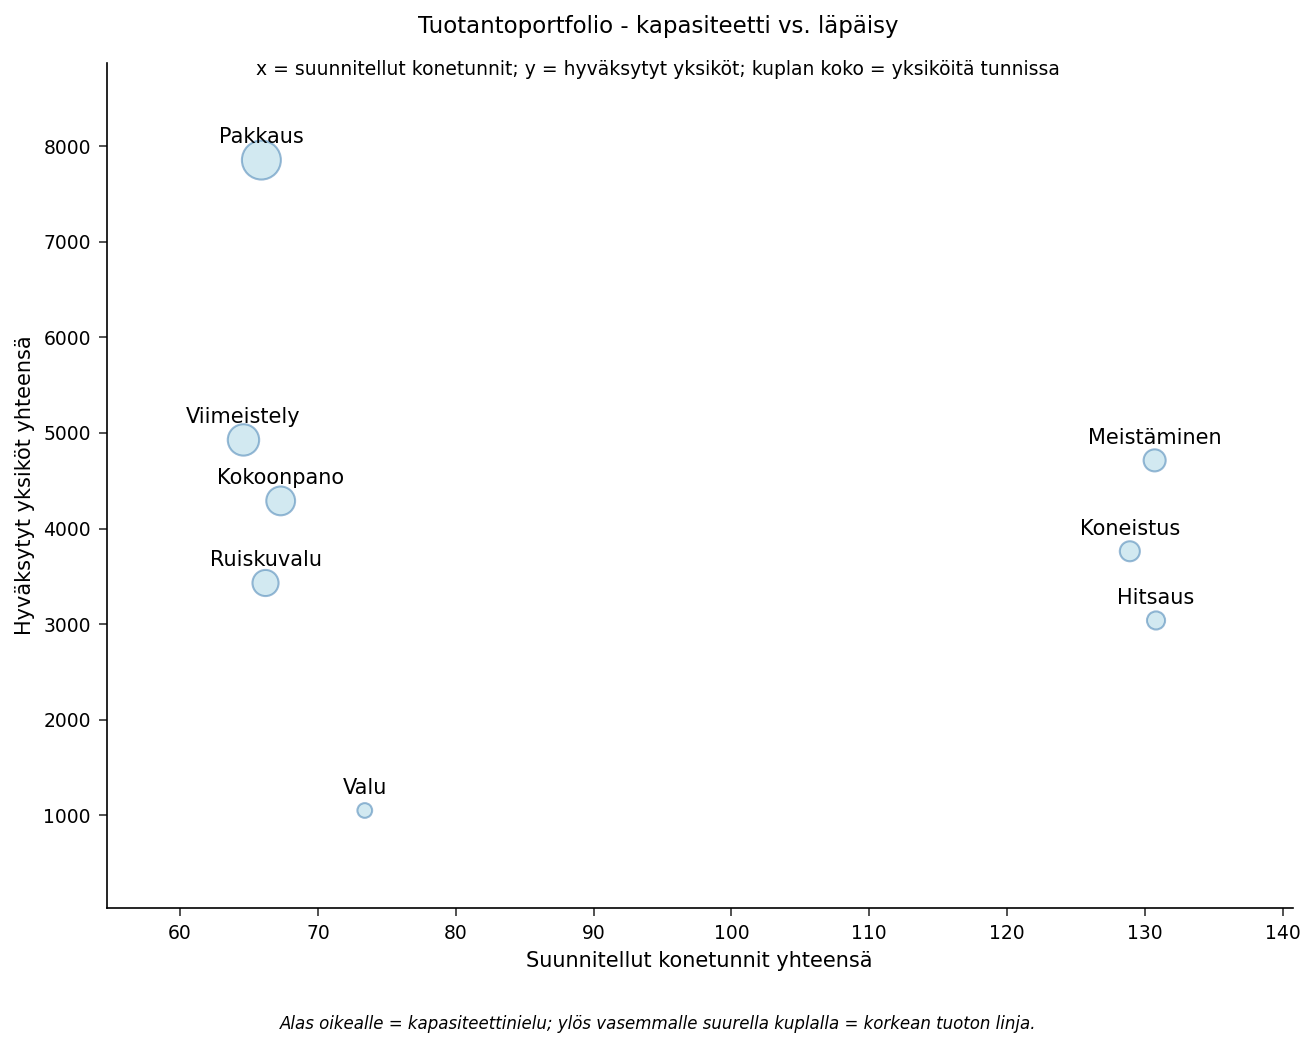

In [4]:
OTSIKKO "Tuotantoportfolio - kapasiteetti vs. läpäisy";
title2 "x = suunnitellut konetunnit; y = hyväksytyt yksiköt; kuplan koko = yksiköitä tunnissa";
footnote JUSTIFY=LEFT
    "Alas oikealle = kapasiteettinielu; ylös vasemmalle suurella kuplalla = korkean tuoton linja.";

PROSEDUURI SGPLOT TIEDOT=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS NIMIKE="Suunnitellut konetunnit yhteensä";
    YAXIS NIMIKE="Hyväksytyt yksiköt yhteensä";
SUORITA;

OTSIKKO; title2; footnote;

## 5. Läpäisy linjoittain, jaoteltu tehtaittain

Nähdäksemme, miten kunkin linjan tuotanto jakautuu kolmen tehtaan kesken, `VBAR product_line / response=good_units group=plant` -kaavio pinoaa tehtaiden osuudet kunkin pylvään sisään. Tämä on segmentointinäkymä: se näyttää sekä kokonaiskorkeuden (hyväksytyt yksiköt linjaa kohden) että tehdasjakauman kunkin pylvään sisällä, joten voit havaita linjat, joissa yksi tehdas hallitsee tuotantoa.

                             Hyväksytyt yksiköt tuotantolinjoittain, pinottuna tehtaittain                              
                        Pylvään korkeus = hyväksytyt yksiköt yhteensä; segmentit = tehtaan osuus                        




NOTE: Option TITLE changed to Hyväksytyt yksiköt tuotantolinjoittain, pinottuna tehtaittain.
NOTE: Option TITLE2 changed to Pylvään korkeus = hyväksytyt yksiköt yhteensä; segmentit = tehtaan osuus.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


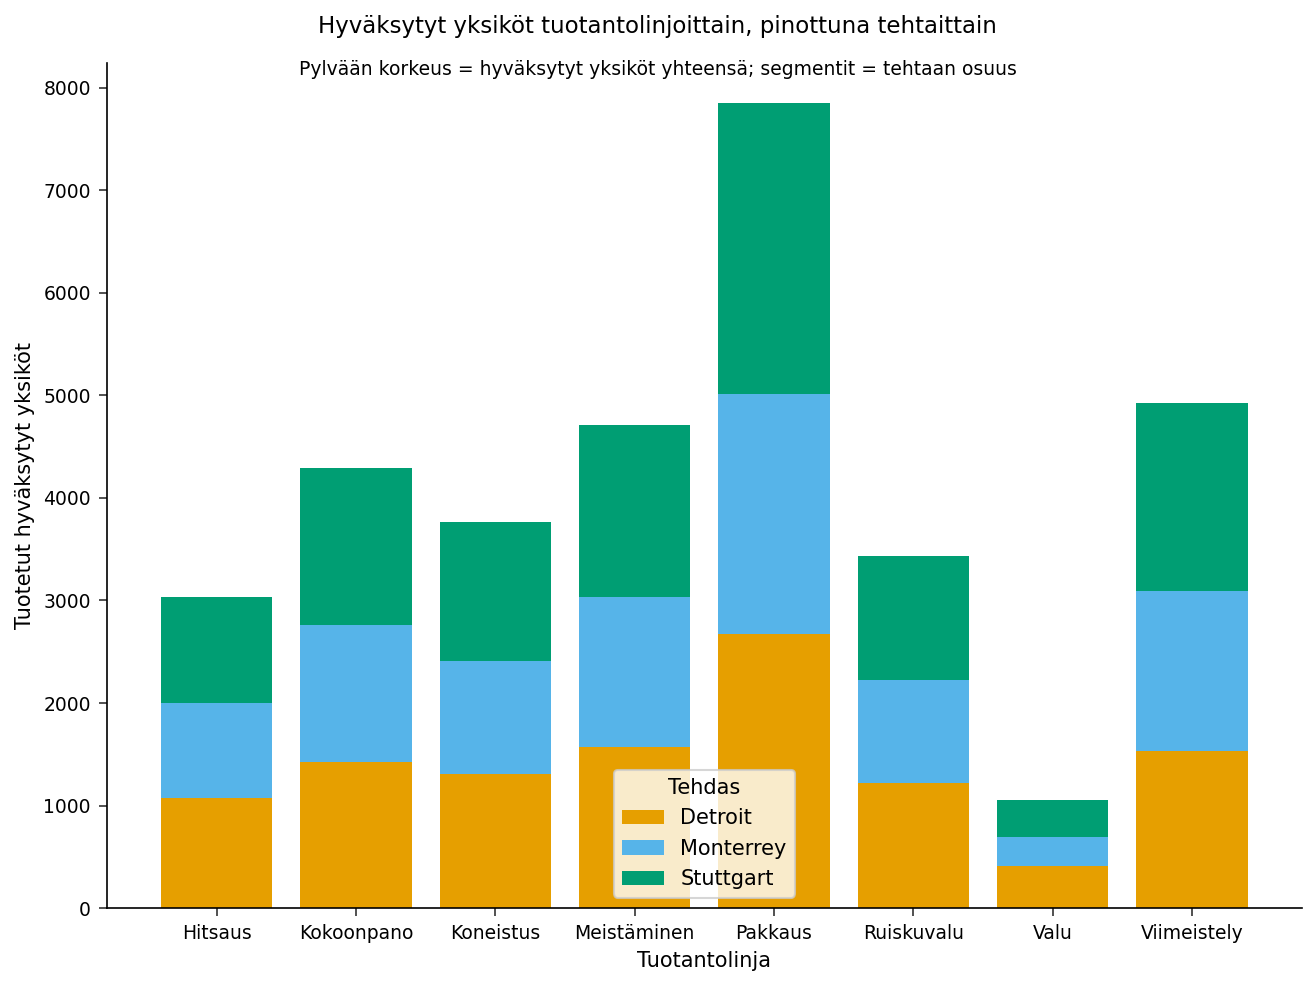

In [5]:
OTSIKKO "Hyväksytyt yksiköt tuotantolinjoittain, pinottuna tehtaittain";
title2 "Pylvään korkeus = hyväksytyt yksiköt yhteensä; segmentit = tehtaan osuus";

PROSEDUURI SGPLOT TIEDOT=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS NIMIKE="Tuotantolinja" fitpolicy=ROTATE;
    YAXIS NIMIKE="Tuotetut hyväksytyt yksiköt";
    keylegend / OTSIKKO="Tehdas" position=bottom;
SUORITA;

OTSIKKO; title2;

## 6. Yhden tehtaan tuottavuuden syväluotaus (WHERE)

Vaakapylväät (`HBAR`) sopivat pitkille tuotantolinjan nimille. `WHERE`-lauseke rajaa aineiston Stuttgartin tehtaaseen, ja pylväät piirretään muuttujalle `units_per_hr`, joten kaavio järjestää Stuttgartin linjat tuottavuuden mukaan. Koska syöte on lajiteltu nousevasti asteen mukaan, vähiten tuottava linja on alimpana ja tuottavin ylimpänä.

                             Stuttgartin tehdas - linjat tuottavuuden mukaan järjestettynä                              


Pylvään pituus = hyväksyttyjä yksiköitä konetuntia kohden (yhden tehtaan syväluotaus).



NOTE: Option TITLE changed to Stuttgartin tehdas - linjat tuottavuuden mukaan järjestettynä.
NOTE: Option FOOTNOTE changed to Pylvään pituus = hyväksyttyjä yksiköitä konetuntia kohden (yhden tehtaan syväluotaus)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


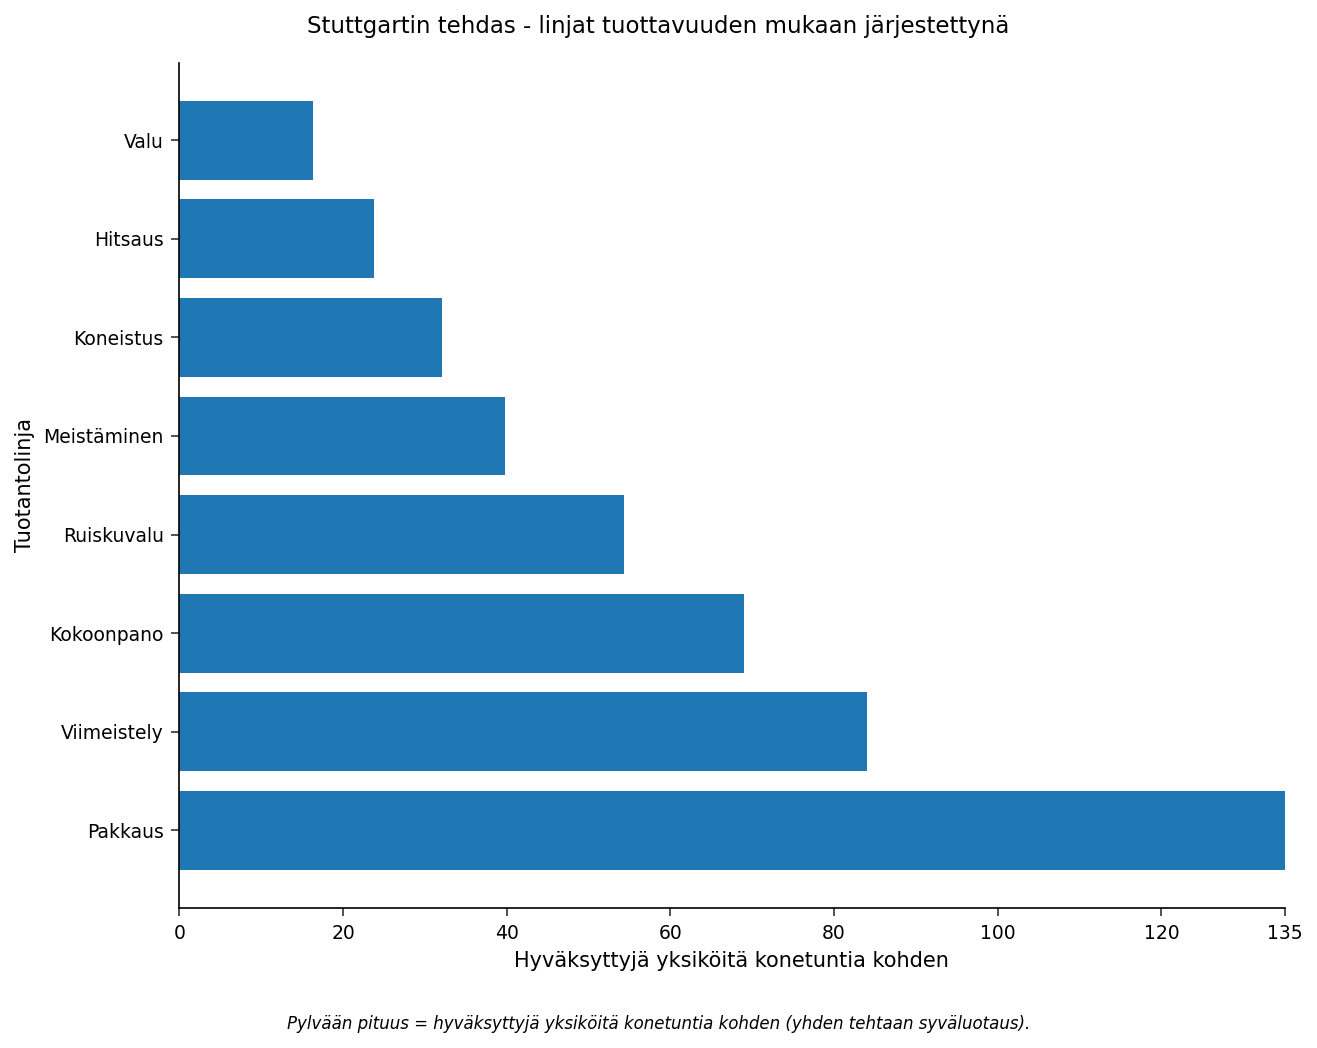

In [6]:
OTSIKKO "Stuttgartin tehdas - linjat tuottavuuden mukaan järjestettynä";
footnote JUSTIFY=LEFT "Pylvään pituus = hyväksyttyjä yksiköitä konetuntia kohden (yhden tehtaan syväluotaus).";

PROSEDUURI SGPLOT TIEDOT=work.line_capacity;
    MISSÄ plant = "Stuttgart";
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS NIMIKE="Hyväksyttyjä yksiköitä konetuntia kohden";
    YAXIS NIMIKE="Tuotantolinja";
SUORITA;

OTSIKKO; footnote;

## 7. Rinnakkainen tehdasvertailu (ryhmitellyt pylväät)

Vertaillaksemme kolmea tehdasta linja linjalta, ryhmitelty pylväskaavio (`GROUPDISPLAY=CLUSTER`) piirtää Detroitin, Monterreyn ja Stuttgartin vierekkäisinä pylväinä kunkin tuotantolinjan sisällä. Tämä on suora tehdasvertailu: minkä tahansa linjan kohdalla voit lukea, mikä tehdas tuotti eniten hyväksyttyjä yksiköitä, mikä tekee tehtaiden tehokkuuserot (Stuttgart korkein, Monterrey matalin) suoraan näkyviksi.

                               Hyväksytyt yksiköt linjoittain ja tehtaittain - rinnakkain                               
                      Ryhmitellyt pylväät: yksi pylväs tehdasta kohden jokaisessa tuotantolinjassa                      




NOTE: Option TITLE changed to Hyväksytyt yksiköt linjoittain ja tehtaittain - rinnakkain.
NOTE: Option TITLE2 changed to Ryhmitellyt pylväät: yksi pylväs tehdasta kohden jokaisessa tuotantolinjassa.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


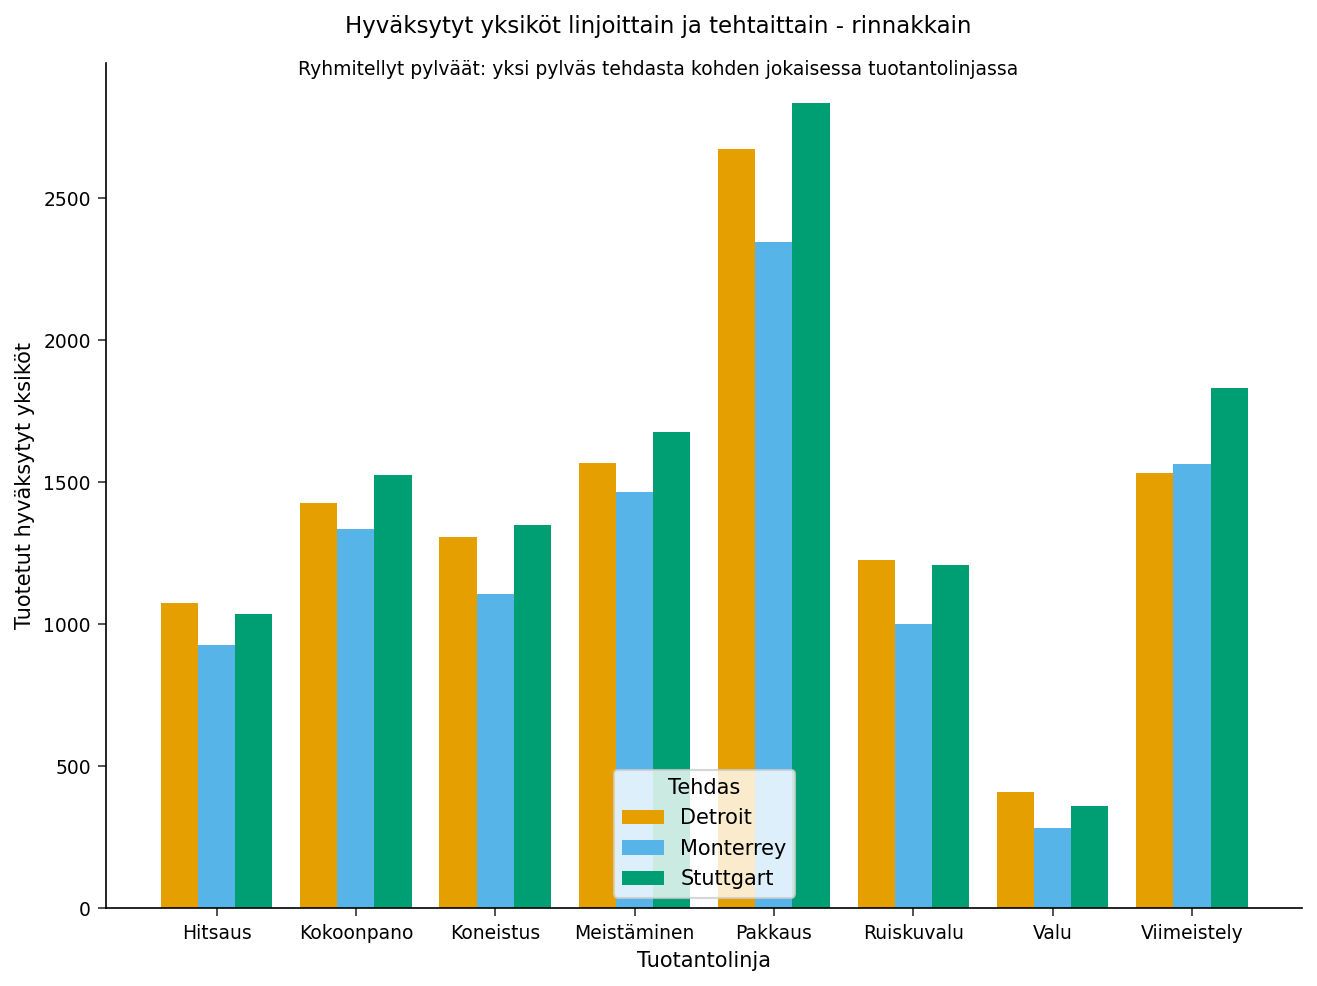

In [7]:
OTSIKKO "Hyväksytyt yksiköt linjoittain ja tehtaittain - rinnakkain";
title2 "Ryhmitellyt pylväät: yksi pylväs tehdasta kohden jokaisessa tuotantolinjassa";

PROSEDUURI SGPLOT TIEDOT=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS NIMIKE="Tuotantolinja" fitpolicy=ROTATE;
    YAXIS NIMIKE="Tuotetut hyväksytyt yksiköt";
    keylegend / OTSIKKO="Tehdas" position=bottom;
SUORITA;

OTSIKKO; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Tulkinta

Kapasiteetin ja läpäisyn piirtäminen samoille akseleille paljastaa yhteyden, jonka yksiulotteinen pylväskaavio kätkisi. **Valu** on portfolion selkein kapasiteettinielu: tuottavuusjärjestyksessä se on alimpana **14,3 hyväksytyllä yksiköllä konetuntia kohden**, ja kuplakaaviossa se putoaa alas vasemmalle pienenä kuplana — se kuluttaa **10,1 %** suunnitelluista kokonaistunneista mutta palauttaa vain **3,2 %** hyväksytyistä yksiköistä (sillä on myös alhaisin saanto, noin 91 %, korkean hylkyosuutensa vuoksi). Se on ensisijainen ehdokas sykliajan lyhentämiseen ja hylyn vähentämiseen tähtäävälle kaizenille. Vastakkaisessa päässä **Pakkaus** on ylivoimainen korkean tuoton linja **119,2 yksiköllä konetuntia kohden** — suuri kupla korkealla läpäisyakselilla, joka muuttaa **9,1 %** kapasiteetista **23,8 %:ksi** kaikista hyväksytyistä yksiköistä; sen käyttöajan suojaaminen tuottaa suhteettoman suurta tuotantoa. **Viimeistely** (76,3 yksikköä/h) ja **Kokoonpano** (63,7) noudattavat samaa korkean tuoton kaavaa.

Kaava on systemaattinen: neljä hidasta, kapasiteettia ahnehtivaa alkupään linjaa — Valu, Hitsaus (23,2 yksikköä/h), Koneistus (29,2) ja Meistäminen (36,1) — kuluttavat yhdessä noin **64 %** suunnitelluista tunneista mutta toimittavat vain noin **38 %** hyväksytyistä yksiköistä, kun taas neljä nopeaa loppupään linjaa tuottavat suhteessa enemmän kuin niiden kuluttamat tunnit edellyttäisivät. Tehtaittain pinottu näkymä ja rinnakkaiset ryhmitellyt pylväät näyttävät tämän taustalla olevan tehdasulottuvuuden: **Stuttgart** käy kuumimmillaan **49,9 hyväksytyllä yksiköllä konetuntia kohden**, **Detroit** on keskitasolla **44,9**:llä ja **Monterrey** jää jälkeen **41,6**:lla — yhdenmukaisesti Monterreyn korkeamman mallinnetun seisokkiajan kanssa. Toiminnallisesti tämä viittaa siihen, että suunniteltuja tunteja kannattaisi tasapainottaa uudelleen kohti korkean tuoton loppupään linjoja ja verrata Monterreyn seisokkiaikaa Stuttgartin käytäntöihin.

*Vain synteettistä dataa — luvut havainnollistavat kaksiulotteista kapasiteetti-vs-läpäisy-visualisointia PROC SGPLOT:lla, eivät todellista tehtaan suorituskykyä.*